# Filtering

In [2]:
from __future__ import annotations

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import matplotlib.colors as mcolors
import numpy as np
import numpy.typing as npt
import xarray as xr

In [5]:
from evaspa.common import filter

In [6]:
# Create a discrete colormap with two colors
cmap = mcolors.ListedColormap(["red", "green"])
bounds = [-0.5, 0.5, 1.5]  # True=1, False=0
norm = mcolors.BoundaryNorm(bounds, cmap.N)

colors = [
    "#d73027",
    "#fc8d59",
    "#fee090",
    "#91bfdb",
    "#4575b4",
]  # choose any 5 colors
# Create colormap and normalization
lulc_cmap = mcolors.ListedColormap(colors)
bounds = [5, 15, 25, 35, 45, 55]  # boundaries between each value
lulc_norm = mcolors.BoundaryNorm(bounds, lulc_cmap.N)

## Detect valid pixels

### Inputs

In [7]:
np.random.seed(0)
size = 100
lst = np.random.randint(low=290, high=300, size=(size, size))
clear = np.random.choice([0, 1], size=(size, size), p=[0.2, 0.8])
water = np.random.choice([0, 1], size=(size, size), p=[0.9, 0.1])
lulc = np.random.choice(
    [10, 20, 30, 40, 50], size=(size, size), p=[0.6, 0.1, 0.1, 0.1, 0.1]
)

In [8]:
data = xr.Dataset(
    data_vars={
        "lst": (["y", "x"], lst),
        "clear": (["y", "x"], clear),
        "water": (["y", "x"], water),
        "lulc": (["y", "x"], lulc),
    },
    coords={
        "y": ("y", np.arange(size)),
        "x": ("x", np.arange(size)),
    },
    attrs={"description": "Test data"},
)

In [9]:
data

<xarray.Dataset> Size: 322kB
Dimensions:  (y: 100, x: 100)
Coordinates:
  * y        (y) int64 800B 0 1 2 3 4 5 6 7 8 9 ... 91 92 93 94 95 96 97 98 99
  * x        (x) int64 800B 0 1 2 3 4 5 6 7 8 9 ... 91 92 93 94 95 96 97 98 99
Data variables:
    lst      (y, x) int64 80kB 295 290 293 293 297 299 ... 292 298 290 298 290
    clear    (y, x) int64 80kB 0 1 1 1 0 1 1 1 1 1 1 1 ... 1 0 1 1 0 1 1 1 1 0 1
    water    (y, x) int64 80kB 0 0 0 1 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 1 0 0 1 0 0
    lulc     (y, x) int64 80kB 20 10 10 10 10 10 20 10 ... 30 10 10 10 10 10 20
Attributes:
    description:  Test data

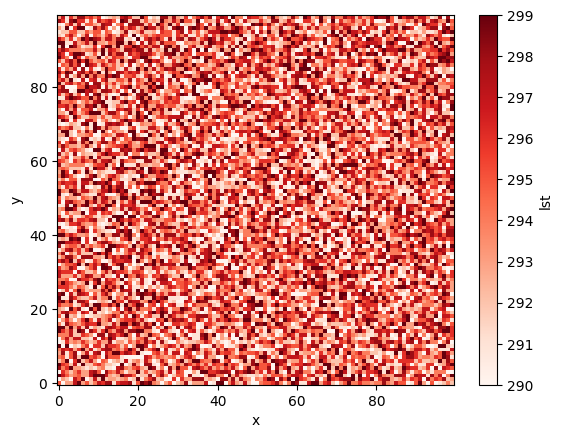

In [10]:
data["lst"].plot(cmap="Reds")

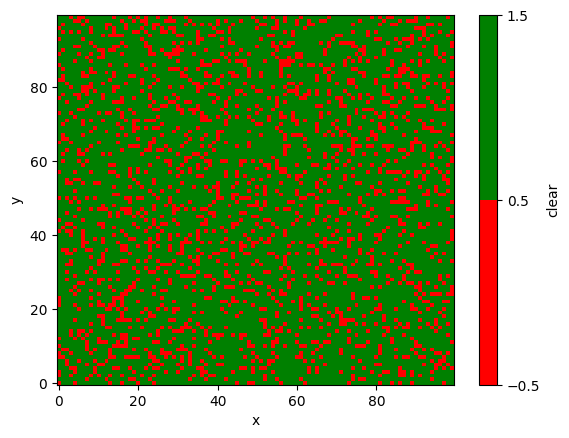

In [11]:
data["clear"].plot(cmap=cmap, norm=norm)

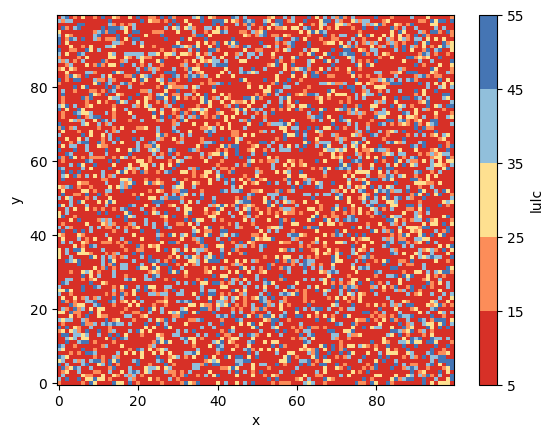

In [12]:
data["lulc"].plot(cmap=lulc_cmap, norm=lulc_norm)

### Simple case

In [13]:
config = {
    "clear": {"op": "==", "value": 1},
}

In [14]:
config

{'clear': {'op': '==', 'value': 1}}

In [15]:
filter.FilteringConfig.model_validate(config)

FilteringConfig(root={'clear': SimpleCondition(op='==', value=1.0)})

In [16]:
valid = filter.detect_valid_pixels(data, config=config)

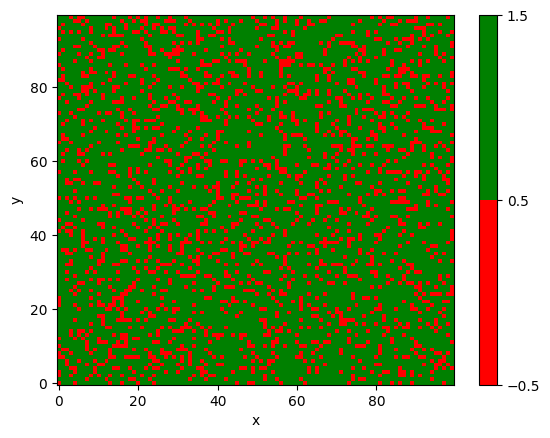

In [17]:
valid.plot(cmap=cmap, norm=norm)

### More complex cases

In [18]:
config1 = {
    "lst": {"and": [{"op": ">", "value": 291}, {"op": "<", "value": 298}]},
}

In [19]:
config2 = {
    "clear": {"op": "==", "value": 1},
    "water": {"op": "!=", "value": 1},
}

In [20]:
config3 = {
    "lulc": {
        "or": [{"op": "==", "value": 10}, {"op": "==", "value": 20}],
    }
}

In [21]:
config = config1

In [22]:
filter.FilteringConfig.model_validate(config)

FilteringConfig(root={'lst': CompositeCondition(and_=[SimpleCondition(op='>', value=291.0), SimpleCondition(op='<', value=298.0)], or_=None)})

In [23]:
valid = filter.detect_valid_pixels(data, config)

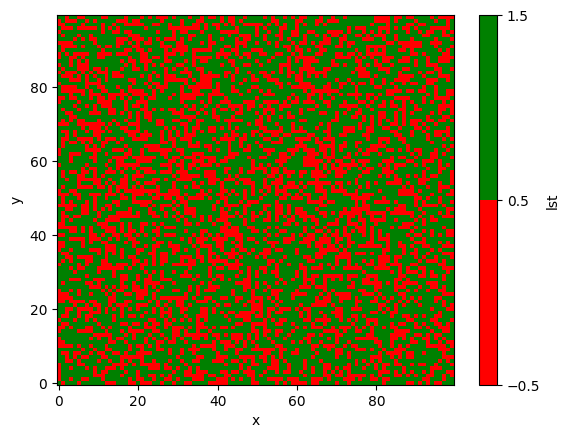

In [24]:
valid.plot(cmap=cmap, norm=norm)

### Combined case

In [25]:
config = {
    "lst": {"and": [{"op": ">", "value": 291}, {"op": "<", "value": 298}]},
    "clear": {"op": "==", "value": 1},
    "water": {"op": "!=", "value": 1},
    "lulc": {
        "and": [{"op": "!=", "value": 40}, {"op": "!=", "value": 50}],
    },
}

In [26]:
config

{'lst': {'and': [{'op': '>', 'value': 291}, {'op': '<', 'value': 298}]},
 'clear': {'op': '==', 'value': 1},
 'water': {'op': '!=', 'value': 1},
 'lulc': {'and': [{'op': '!=', 'value': 40}, {'op': '!=', 'value': 50}]}}

In [27]:
filter.FilteringConfig.model_validate(config)

FilteringConfig(root={'lst': CompositeCondition(and_=[SimpleCondition(op='>', value=291.0), SimpleCondition(op='<', value=298.0)], or_=None), 'clear': SimpleCondition(op='==', value=1.0), 'water': SimpleCondition(op='!=', value=1.0), 'lulc': CompositeCondition(and_=[SimpleCondition(op='!=', value=40.0), SimpleCondition(op='!=', value=50.0)], or_=None)})

In [28]:
valid = filter.detect_valid_pixels(data, config)

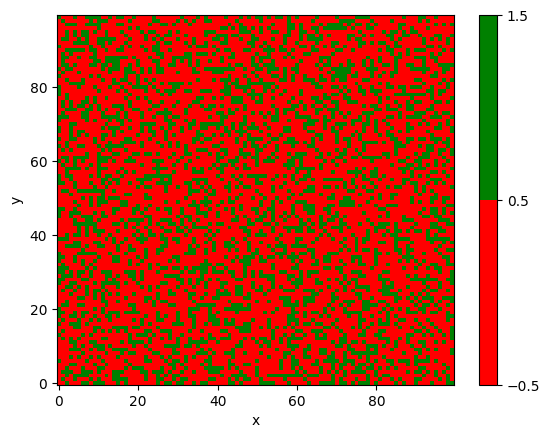

In [29]:
valid.plot(cmap=cmap, norm=norm)

## Detect nan pixels

### Inputs

In [30]:
# Generate a random mask
def random_mask(fraction: float) -> npt.NDArray:
    return np.random.rand(*lst.shape) < fraction

In [31]:
np.random.seed(0)
size = 10
lst = np.random.randint(low=290, high=300, size=(size, size))
albedo = np.random.uniform(low=0.2, high=0.5, size=(size, size))
# Define the fraction of values to replace with NaN
fraction_to_replace = 0.1  # 30%
# Replace values with NaN
lst_with_nan = np.where(~random_mask(0.2), lst, np.nan)
albedo_with_nan = np.where(~random_mask(0.1), albedo, np.nan)

In [32]:
data = xr.Dataset(
    data_vars={
        "lst": (["y", "x"], lst_with_nan),
        "albedo": (["y", "x"], albedo_with_nan),
    },
    coords={
        "y": ("y", np.arange(size)),
        "x": ("x", np.arange(size)),
    },
    attrs={"description": "Test data"},
)

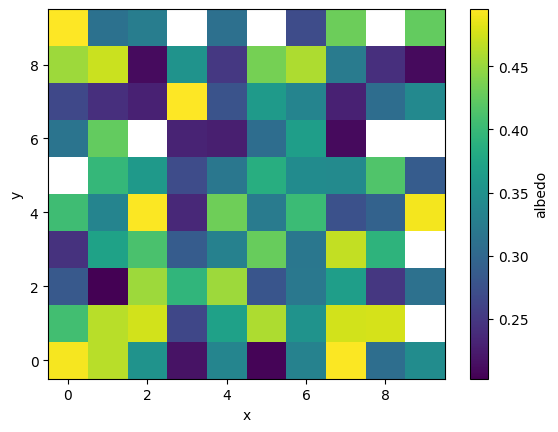

In [33]:
data["albedo"].plot()

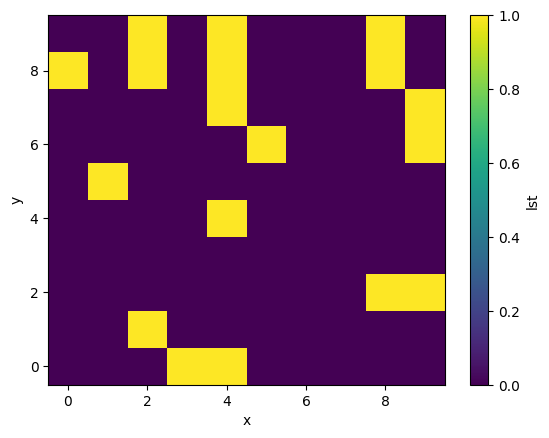

In [34]:
nan_mask = filter.detect_nan_pixels(data, ["lst"])
nan_mask.plot()

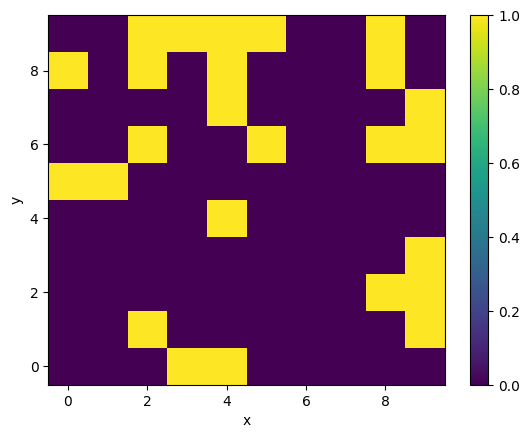

In [35]:
nan_mask = filter.detect_nan_pixels(data, "all")
nan_mask.plot()